# Attenuation Bias with Multivariate Correlated Features

This tutorial extends the single-variate analysis to **multivariate inputs with correlated features** ($p = 10$). This scenario is highly relevant for astronomical applications:

- **Stellar spectra**: Many wavelength pixels respond to the same underlying physical parameters (temperature, metallicity, surface gravity)
- **Photometric redshifts**: Multiple bandpasses are correlated through the underlying galaxy SED

When features are correlated, the effective dimensionality is lower than the number of features, which affects how attenuation bias manifests.

For theoretical background, see [Ting et al. (2025)](https://arxiv.org/abs/placeholder).

---
## 1. Setup

We import the necessary libraries and configure the plotting style. We also set up parallelization for running multiple simulations to obtain stable results with error estimates.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
from joblib import Parallel, delayed

from latentnn import (
    train_mlp, train_latent_mlp,
    predict_mlp, predict_latent,
    generate_correlated_data, calc_lambda, theoretical_attenuation
)

np.random.seed(42)
torch.manual_seed(42)

# Parallelization settings (for stable results)
N_JOBS = 8   # Number of parallel workers
N_SIMS = 8   # Number of simulations per configuration

# Plotting style
plt.rc('text', usetex=False)
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 16,
    'axes.grid': True,
    'grid.alpha': 0.3
})

CB_BLUE = '#4477AA'
CB_RED = '#EE6677'
CB_GREEN = '#228833'
CB_ORANGE = '#CCBB44'

print('Setup complete')

Setup complete


---
## 2. Correlated Multivariate Data

### The Data Model

We model correlated features by deriving all $p = 10$ features from a single underlying latent variable $z$:

$$x_{\mathrm{true}, j} = w_j \cdot z + b_j, \quad j = 1, \ldots, p$$

where $w_j$ and $b_j$ are random coefficients. This mimics spectral pixels responding to the same physical parameter (e.g., metallicity affecting multiple absorption lines).

The observed data includes measurement errors:

$$x_{\mathrm{obs}, j} = x_{\mathrm{true}, j} + \delta_{x,j}, \quad \delta_{x,j} \sim \mathcal{N}(0, \sigma_x^2)$$

### Why Correlated Features Partially Mitigate Attenuation

In the single-variate case, the noise direction is perfectly aligned with the signal direction. With correlated multivariate features:
- The signal lives in a low-dimensional subspace
- Noise is isotropic in the full $p$-dimensional space
- Only the noise component along the signal direction causes attenuation

This geometric effect means that higher-dimensional inputs with strong correlations experience less attenuation than independent features would.

In [12]:
P = 10
SNR_X = 3
SNR_Y = 30

data = generate_correlated_data(n_samples=100, p=P, snr_x=SNR_X, snr_y=SNR_Y, seed=42)
print(f'X_true shape: {data["X_true"].shape}')

X_true shape: (100, 10)


---
## 3. LatentNN Demonstration

We train both a standard MLP and LatentNN with $p = 10$ correlated features at $\mathrm{SNR}_x = 2$. 

### Network Architecture

Both models use identical network architectures:
- **Hidden layers**: 2 layers with 16 units each (for faster execution)
- **Activation**: ReLU
- **Output**: Single regression target
- **Epochs**: 5000

The only difference is that LatentNN also learns latent input values $x_{\mathrm{latent}}$, one per training sample.

### Hyperparameter Tuning

For LatentNN, we search over `weight_decay` values and select the one that gives $\lambda$ closest to 1 on the validation set. This is critical because:
- Too small `weight_decay` → overcorrection ($\lambda > 1$)
- Too large `weight_decay` → undercorrection ($\lambda < 1$)

We use a three-way split (train/validation/test) to avoid data leakage.

In [13]:
P = 10
SNR_X = 2.0
SNR_Y = 30.0
N_TRAIN, N_VAL, N_TEST = 1000, 200, 200

data = generate_correlated_data(N_TRAIN + N_VAL + N_TEST, P, SNR_X, SNR_Y, seed=42)

train = {k: v[:N_TRAIN] for k, v in data.items() if isinstance(v, np.ndarray)}
val = {k: v[N_TRAIN:N_TRAIN+N_VAL] for k, v in data.items() if isinstance(v, np.ndarray)}
test = {k: v[N_TRAIN+N_VAL:] for k, v in data.items() if isinstance(v, np.ndarray)}
sigma_x, sigma_y = data['sigma_x'], data['sigma_y']

print(f'Data: {N_TRAIN} train, {N_VAL} val, {N_TEST} test')

Data: 1000 train, 200 val, 200 test


### Training the Standard MLP

First, we train a standard MLP as our baseline. This model treats the observed inputs $X_{\mathrm{obs}}$ as exact, which leads to attenuation bias.


### LatentNN with weight_decay Search

Now we train LatentNN. The key difference from the standard MLP is that LatentNN jointly optimizes:
1. Network parameters $\theta$ (with weight decay regularization)
2. Latent input values $x_{\mathrm{latent}}$ (regularized by the likelihood term, no weight decay)

We search over `weight_decay` values to find the one that gives $\lambda$ closest to 1 on validation.


In [14]:
# Network architecture parameters
# NOTE: For faster execution, we use a smaller network (16 nodes) and fewer epochs (5000).
#       For better results matching the paper, use hidden_size=64, epochs=20000.
HIDDEN_SIZE = 16
NUM_LAYERS = 2
EPOCHS = 5000
LR = 0.03

print('Training Standard MLP...')
torch.manual_seed(42)
model_mlp = train_mlp(
    train['X_obs'], train['y_obs'],
    hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    epochs=EPOCHS, lr=LR, weight_decay=0.001
)

Training Standard MLP...


In [15]:
# Search for best weight_decay for LatentNN
print('Searching weight_decay for LatentNN...')
weight_decays = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
best_wd, best_lam = None, 0

for wd in weight_decays:
    torch.manual_seed(42)
    model = train_latent_mlp(
        train['X_obs'], train['y_obs'], sigma_x, sigma_y,
        hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
        epochs=EPOCHS, lr=LR, weight_decay=wd,
        x_val=val['X_obs'], y_true_val=val['y_true']
    )
    lam, _ = calc_lambda(val['y_true'], predict_latent(model, val['X_obs']))
    print(f'  wd={wd:.4f}: λ_val={lam:.4f}')
    
    if best_wd is None or abs(lam - 1.0) < abs(best_lam - 1.0):
        best_wd, best_lam = wd, lam

print(f'Best weight_decay = {best_wd}')

# Train final model with best weight_decay
print('\nTraining final LatentNN...')
torch.manual_seed(42)
model_latent, losses = train_latent_mlp(
    train['X_obs'], train['y_obs'], sigma_x, sigma_y,
    hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    epochs=EPOCHS, lr=LR, weight_decay=best_wd,
    x_val=val['X_obs'], y_true_val=val['y_true'],
    return_losses=True
)

Searching weight_decay for LatentNN...
  wd=0.0001: λ_val=0.9463
  wd=0.0003: λ_val=0.9383
  wd=0.0010: λ_val=0.9564
  wd=0.0030: λ_val=0.9409
  wd=0.0100: λ_val=0.9465
  wd=0.0300: λ_val=0.9514
  wd=0.1000: λ_val=0.9442
Best weight_decay = 0.001

Training final LatentNN...


### Evaluation on Test Set

We evaluate both models on the held-out test set. The theoretical attenuation for linear regression with $p$ correlated features is shown for reference, though neural networks may deviate somewhat from this prediction.


In [16]:
y_pred_mlp = predict_mlp(model_mlp, test['X_obs'])
y_pred_latent = predict_latent(model_latent, test['X_obs'])

lam_mlp, int_mlp = calc_lambda(test['y_true'], y_pred_mlp)
lam_latent, int_latent = calc_lambda(test['y_true'], y_pred_latent)
lam_theory = theoretical_attenuation(SNR_X, p=P)

print(f'Theory:        λ = {lam_theory:.3f}')
print(f'Standard MLP:  λ = {lam_mlp:.3f}')
print(f'LatentNN:      λ = {lam_latent:.3f}')

Theory:        λ = 0.790
Standard MLP:  λ = 0.803
LatentNN:      λ = 0.966


### Visual Comparison

The scatter plots below show $y_{\mathrm{pred}}$ vs $y_{\mathrm{true}}$ for both models. The black dashed line shows perfect predictions ($\lambda = 1$), while the red line shows the actual fitted slope. Despite the multivariate input, we see the same pattern: the standard MLP exhibits attenuation while LatentNN corrects it.


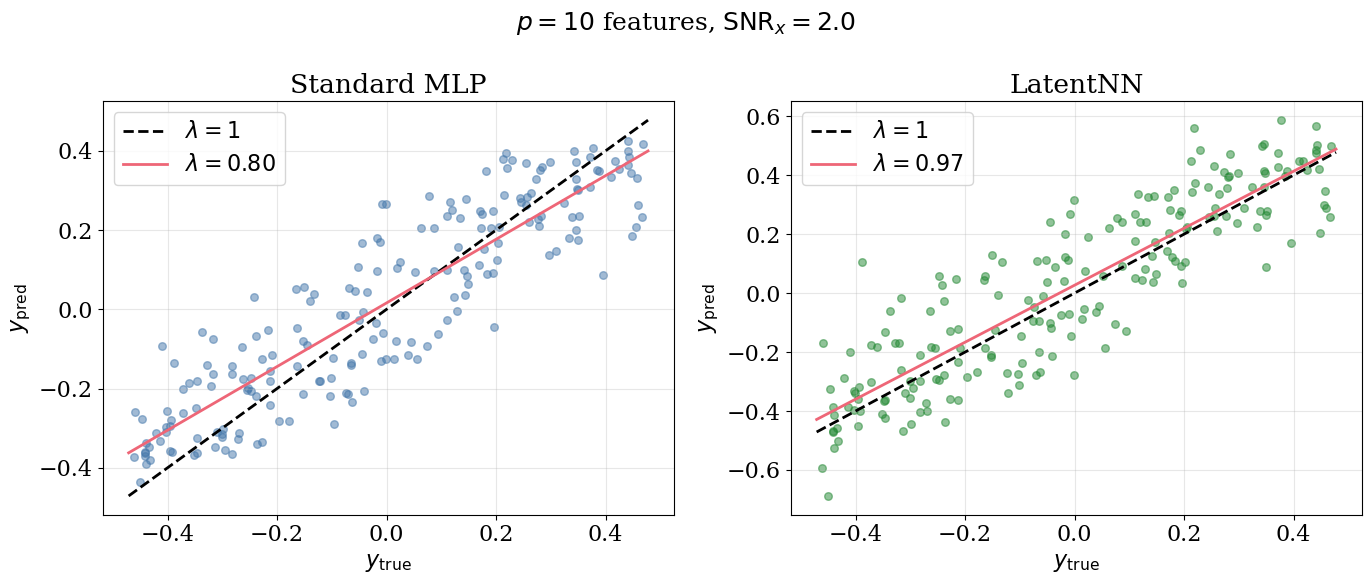

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
y_min, y_max = test['y_true'].min() - 0.01, test['y_true'].max() + 0.01

for ax, y_pred, lam, intercept, title, color in [
    (axes[0], y_pred_mlp, lam_mlp, int_mlp, 'Standard MLP', CB_BLUE),
    (axes[1], y_pred_latent, lam_latent, int_latent, 'LatentNN', CB_GREEN)
]:
    ax.scatter(test['y_true'], y_pred, alpha=0.5, s=30, c=color)
    ax.plot([y_min, y_max], [y_min, y_max], 'k--', lw=2, label='$\\lambda = 1$')
    ax.plot([y_min, y_max], [lam*y_min+intercept, lam*y_max+intercept],
            '-', color=CB_RED, lw=2, label=f'$\\lambda = {lam:.2f}$')
    ax.set_xlabel('$y_{\\mathrm{true}}$')
    ax.set_ylabel('$y_{\\mathrm{pred}}$')
    ax.set_title(title)
    ax.legend(loc='upper left')

plt.suptitle(f'$p = {P}$ features, $\\mathrm{{SNR}}_x = {SNR_X}$', fontsize=18)
plt.tight_layout()
plt.show()

---
## 4. Systematic Comparison Across SNR Values

We verify that LatentNN corrects attenuation across a range of SNR values for $p = 10$ correlated features. For each SNR, we:
1. Run hyperparameter search on the validation set
2. Run 8 parallel simulations with different seeds
3. Report mean ± std of the attenuation factor on the test set

In [18]:
snr_x_values = np.array([1, 2, 3, 5, 10])
weight_decays = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
results = {'mlp': {'mean': [], 'std': []}, 'latent': {'mean': [], 'std': []}, 'theory': []}

print(f'Running systematic comparison ({N_SIMS} simulations per SNR)...')
print('Note: HP search uses validation set; final eval uses test set')
print()

for snr_x in snr_x_values:
    # HP search using seed=42
    data_hp = generate_correlated_data(N_TRAIN + N_VAL + N_TEST, P, snr_x, SNR_Y, seed=42)
    train_hp = {k: v[:N_TRAIN] for k, v in data_hp.items() if isinstance(v, np.ndarray)}
    val_hp = {k: v[N_TRAIN:N_TRAIN+N_VAL] for k, v in data_hp.items() if isinstance(v, np.ndarray)}
    sigma_x, sigma_y = data_hp['sigma_x'], data_hp['sigma_y']
    
    # LatentNN: select weight_decay by λ on validation set
    best_wd_lat, best_lam = None, 0
    for wd in weight_decays:
        torch.manual_seed(42)
        m = train_latent_mlp(train_hp['X_obs'], train_hp['y_obs'], sigma_x, sigma_y,
                             hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                             epochs=EPOCHS, lr=LR, weight_decay=wd,
                             x_val=val_hp['X_obs'], y_true_val=val_hp['y_true'])
        lam, _ = calc_lambda(val_hp['y_true'], predict_latent(m, val_hp['X_obs']))
        if best_wd_lat is None or abs(lam - 1) < abs(best_lam - 1):
            best_wd_lat, best_lam = wd, lam
    
    # MLP: select weight_decay by loss on validation set
    best_wd_mlp, best_loss = None, float('inf')
    for wd in weight_decays:
        torch.manual_seed(42)
        m = train_mlp(train_hp['X_obs'], train_hp['y_obs'],
                      hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                      epochs=EPOCHS, lr=LR, weight_decay=wd)
        y_p = predict_mlp(m, val_hp['X_obs'])
        vl = np.mean((y_p - val_hp['y_true'])**2)
        if vl < best_loss:
            best_wd_mlp, best_loss = wd, vl
    
    # Run N_SIMS parallel simulations with different seeds
    def run_sim(sim):
        data = generate_correlated_data(N_TRAIN + N_VAL + N_TEST, P, snr_x, SNR_Y, seed=42+sim)
        tr = {k: v[:N_TRAIN] for k, v in data.items() if isinstance(v, np.ndarray)}
        va = {k: v[N_TRAIN:N_TRAIN+N_VAL] for k, v in data.items() if isinstance(v, np.ndarray)}
        te = {k: v[N_TRAIN+N_VAL:] for k, v in data.items() if isinstance(v, np.ndarray)}
        sx, sy = data['sigma_x'], data['sigma_y']
        
        torch.manual_seed(42+sim)
        mlp = train_mlp(tr['X_obs'], tr['y_obs'],
                        hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                        epochs=EPOCHS, lr=LR, weight_decay=best_wd_mlp)
        lam_m, _ = calc_lambda(te['y_true'], predict_mlp(mlp, te['X_obs']))
        
        torch.manual_seed(42+sim)
        lat = train_latent_mlp(tr['X_obs'], tr['y_obs'], sx, sy,
                               hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                               epochs=EPOCHS, lr=LR, weight_decay=best_wd_lat,
                               x_val=va['X_obs'], y_true_val=va['y_true'])
        lam_l, _ = calc_lambda(te['y_true'], predict_latent(lat, te['X_obs']))
        return lam_m, lam_l
    
    sim_results = Parallel(n_jobs=N_JOBS)(delayed(run_sim)(s) for s in range(N_SIMS))
    mlp_lams = [r[0] for r in sim_results]
    lat_lams = [r[1] for r in sim_results]
    
    lam_theory = theoretical_attenuation(snr_x, p=P)
    results['mlp']['mean'].append(np.mean(mlp_lams))
    results['mlp']['std'].append(np.std(mlp_lams))
    results['latent']['mean'].append(np.mean(lat_lams))
    results['latent']['std'].append(np.std(lat_lams))
    results['theory'].append(lam_theory)
    
    print(f'  SNR_x = {snr_x:2d}:  MLP λ = {np.mean(mlp_lams):.3f}±{np.std(mlp_lams):.3f},  LatentNN λ = {np.mean(lat_lams):.3f}±{np.std(lat_lams):.3f}')

Running systematic comparison (8 simulations per SNR)...
Note: HP search uses validation set; final eval uses test set

  SNR_x =  1:  MLP λ = 0.492±0.025,  LatentNN λ = 0.834±0.030
  SNR_x =  2:  MLP λ = 0.805±0.020,  LatentNN λ = 0.974±0.015
  SNR_x =  3:  MLP λ = 0.900±0.018,  LatentNN λ = 0.996±0.008
  SNR_x =  5:  MLP λ = 0.963±0.010,  LatentNN λ = 1.004±0.011
  SNR_x = 10:  MLP λ = 0.987±0.005,  LatentNN λ = 1.002±0.007


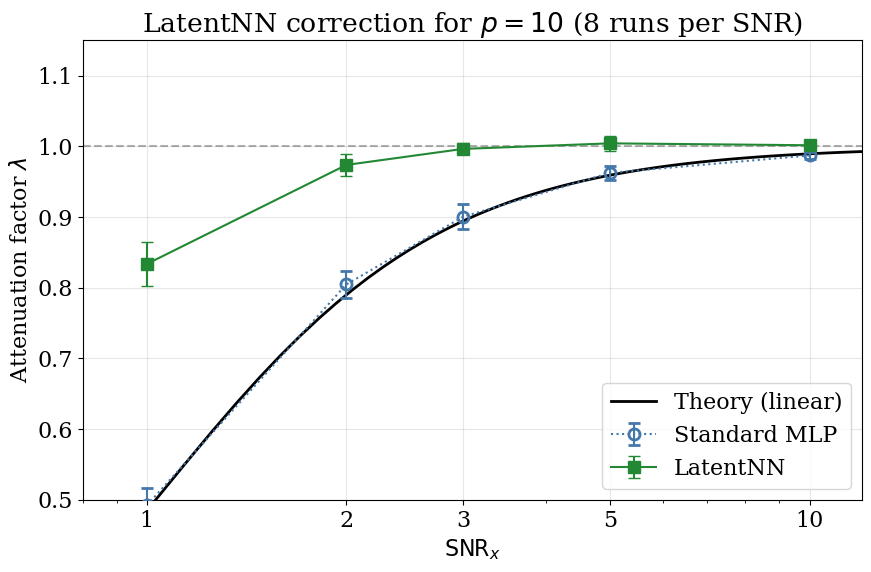

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

snr_theory = np.linspace(0.8, 12, 100)
ax.plot(snr_theory, [theoretical_attenuation(s, p=P) for s in snr_theory],
        'k-', lw=2, label='Theory (linear)')

ax.errorbar(snr_x_values, results['mlp']['mean'], yerr=results['mlp']['std'],
            fmt='o:', c=CB_BLUE, capsize=4, markersize=8, markerfacecolor='none',
            markeredgewidth=2, lw=1.5, label='Standard MLP', zorder=5)
ax.errorbar(snr_x_values, results['latent']['mean'], yerr=results['latent']['std'],
            fmt='s-', c=CB_GREEN, capsize=4, markersize=8, lw=1.5,
            label='LatentNN', zorder=5)

ax.axhline(1.0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('$\\mathrm{SNR}_x$')
ax.set_ylabel('Attenuation factor $\\lambda$')
ax.set_xscale('log')
ax.set_xlim(0.8, 12)
ax.set_xticks(snr_x_values)
ax.set_xticklabels([str(x) for x in snr_x_values])
ax.set_ylim(0.5, 1.15)
ax.legend(loc='lower right')
ax.set_title(f'LatentNN correction for $p = {P}$ ({N_SIMS} runs per SNR)')
plt.tight_layout()
plt.show()

---
## Summary

1. **Correlated features partially mitigate attenuation** because noise in different dimensions does not align coherently with the signal direction. In astronomical applications where features are highly correlated (spectral pixels, photometric bands), the effective attenuation is less severe than for independent inputs.

2. **LatentNN works for multivariate inputs** with the same loss function structure. The regularization term becomes:
   $$\frac{1}{\sigma_x^2} \sum_i \sum_j (x_{\mathrm{obs},ij} - x_{\mathrm{latent},ij})^2$$
   summing over all $p$ dimensions.

3. **The same hyperparameter tuning strategy applies**: search over `weight_decay` values and select the one giving $\lambda$ closest to 1 on the validation set.

4. For $p = 10$ correlated features, LatentNN achieves $\lambda \approx 1$ across the tested SNR range, while standard MLPs suffer significant attenuation especially at low SNR.

For the single-variate case and more detailed explanations, see `tutorial_single_variate.ipynb`.